# SPORES Clustering Workbench

This notebook is a configurable analysis workbench for SPORES clustering. It keeps the detailed descriptions and diagnostics close to the code, while the reusable logic lives in `src/calliope_nl_analysis`.

Use it to select a decision variable, compare clustering methods, inspect labels, and export small summary tables.


In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if not (ROOT / "model_files").exists():
    ROOT = ROOT.parent

SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

SPORES_DIR = ROOT / "results" / "spores"
OUTPUT_ROOT = ROOT / "outputs" / "clustering_workbench"

In [2]:
import pandas as pd

from calliope_nl_analysis.spores import list_spore_records, validate_spore_inventory
from calliope_nl_analysis.workbench import (
    PRESETS,
    build_matrix,
    elbow_curve,
    export_workbench_tables,
    fit_all_methods,
    get_preset,
    hierarchical_linkages,
    method_parameter_table,
    nearest_neighbor_distances,
    pca_scores,
    preset_table,
    selected_method_tables,
    validation_metrics,
)
from calliope_nl_analysis.plots import (
    plot_capacity_centroids,
    plot_dendrograms,
    plot_elbow_curve,
    plot_family_heatmap,
    plot_nearest_neighbor_curve,
    plot_pca_scores,
    plot_timeseries_centroids,
    plot_validation_metrics,
)

## Available Presets

Presets are named, reproducible clustering configurations. They define the feature extraction rule, PCA dimension, and method-specific clustering parameters.


In [3]:
preset_table()

,variable,pca_components,kmeans_clusters,dbscan_eps,dbscan_min_samples,ward_cut,complete_cut,single_cut,notes
preset,,,,,,,,,
flow_cap_default,flow_cap,6,4,0.8,12,16.0,5.2,3.1,Default capacity workflow: national technology...
cost_operation_variable_default,cost_operation_variable,2,4,10.0,4,100.0,35.0,14.0,Default time-series workflow: national operati...


## Choose Analysis

Set `ANALYSIS_PRESET` to one of the preset names above. Set `SELECTED_METHOD` to one of `K-means`, `Hier. (Ward)`, `Hier. (Complete)`, `Hier. (Single)`, or `DBSCAN`.

To tune default values or add a decision variable, edit `src/calliope_nl_analysis/workbench.py` near `PRESETS`: add or update an `AnalysisPreset`, then update `build_matrix(...)` if the variable needs a new aggregation rule. Keep this notebook as the clear control panel for selecting the preset and method.


In [4]:
ANALYSIS_PRESET = "flow_cap_default"
# ANALYSIS_PRESET = "cost_operation_variable_default"

SELECTED_METHOD = "Hier. (Single)"
# SELECTED_METHOD = "DBSCAN"
EXPORT_RESULTS = True

preset = get_preset(ANALYSIS_PRESET)
OUTPUT_DIR = OUTPUT_ROOT / preset.key
preset


AnalysisPreset(key='flow_cap_default', label='Capacity clustering defaults', variable='flow_cap', matrix_kind='capacity', pca_components=6, kmeans_clusters=4, dbscan_eps=0.8, dbscan_min_samples=12, hierarchical_cuts={'ward': 16.0, 'complete': 5.2, 'single': 3.1}, notes='Default capacity workflow: national technology capacities, transmission removed, and lost/load import/export demand/curtailment columns dropped.')

In [5]:
inventory = validate_spore_inventory(SPORES_DIR)
records = list_spore_records(SPORES_DIR)
paths = [record.path for record in records]

inventory["total_files"], round(inventory["total_size_bytes"] / 1024**3, 2), inventory["missing_or_incomplete"]

(151, 23.15, {})

## Feature Matrix

For `flow_cap_default`, national technology capacities are used, transmission is removed, and `lost_load`, `import_power`, `export_power`, `demand_power`, and `curtailment` are dropped. For `cost_operation_variable_default`, operation costs are summed nationally per timestep and divided by the 3-hour timestep resolution.


In [6]:
matrix = build_matrix(paths, preset)
matrix.shape

(151, 9)

In [7]:
matrix.head()

techs,battery,bioenergy,ccgt,coal,hydrogen_power_storage,nuclear,solar_pv,wind_offshore,wind_onshore
spore_baseline,0.006340,8894.896356,1004.256616,0.069888,0.000616,485.018742,24359.001444,4756.999928,6953.001947
spore_1,35.657729,9415.177146,1501.003322,273.472884,2.699732,568.870050,24360.847269,4753.963675,6953.988479
spore_2,16.493297,9548.979144,1228.436025,297.931658,1.852852,556.512827,24359.857725,4753.592397,6953.807469
spore_3,6.122457,7606.513316,2516.539649,172.056426,0.816318,527.273198,24359.334582,4753.856489,6953.354895
spore_4,0.029162,6400.811386,0.336087,2633.975679,0.004051,485.091264,24359.001151,4755.914992,7274.454912


## PCA Check

Each preset applies PCA before clustering. This section shows how much variance is retained by the configured number of components.


In [8]:
scores_for_clustering, pca_for_clustering, _ = pca_scores(matrix, n_components=preset.pca_components)
explained_variance = pd.Series(
    pca_for_clustering.explained_variance_ratio_,
    index=[f"PC{i + 1}" for i in range(preset.pca_components)],
    name="explained_variance_ratio",
)
explained_variance.to_frame()

,explained_variance_ratio
PC1,0.263750
PC2,0.151814
PC3,0.121357
PC4,0.120950
PC5,0.120546
PC6,0.119341


In [9]:
explained_variance.cumsum().rename("cumulative_explained_variance").to_frame()

,cumulative_explained_variance
PC1,0.263750
PC2,0.415563
PC3,0.536921
PC4,0.657871
PC5,0.778417
PC6,0.897759


## Cluster-Number Diagnostics

Use these diagnostics to review the configured parameters: K-means elbow curve, hierarchical dendrograms, and DBSCAN nearest-neighbor distances.


(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'flow_cap: K-means elbow'}, xlabel='Number of clusters', ylabel='Inertia'>)

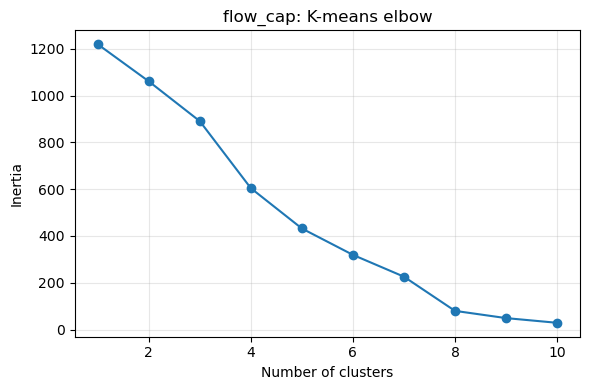

In [10]:
elbow = elbow_curve(matrix, preset)
plot_elbow_curve(elbow, title=f"{preset.variable}: K-means elbow")

(<Figure size 1500x400 with 3 Axes>,
 array([<Axes: title={'center': 'Single'}, xlabel='SPORES', ylabel='Distance'>,
        <Axes: title={'center': 'Complete'}, xlabel='SPORES', ylabel='Distance'>,
        <Axes: title={'center': 'Ward'}, xlabel='SPORES', ylabel='Distance'>],
       dtype=object))

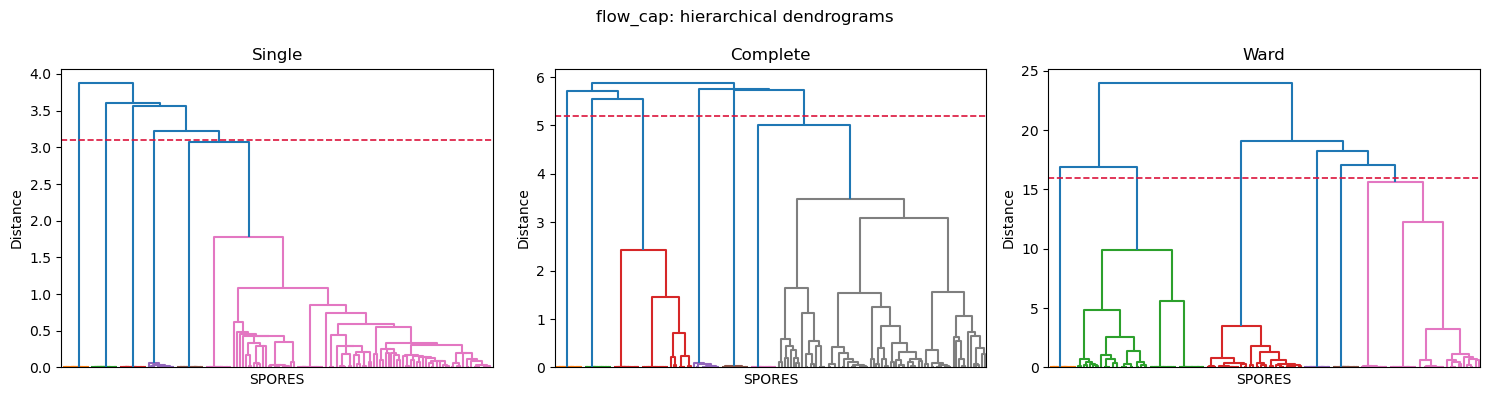

In [11]:
linkages = hierarchical_linkages(matrix, preset)
plot_dendrograms(
    linkages,
    cut_distances=preset.hierarchical_cuts,
    title=f"{preset.variable}: hierarchical dendrograms",
)

(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'flow_cap: DBSCAN nearest-neighbor distances'}, xlabel='Sorted SPORES', ylabel='kth-neighbor distance'>)

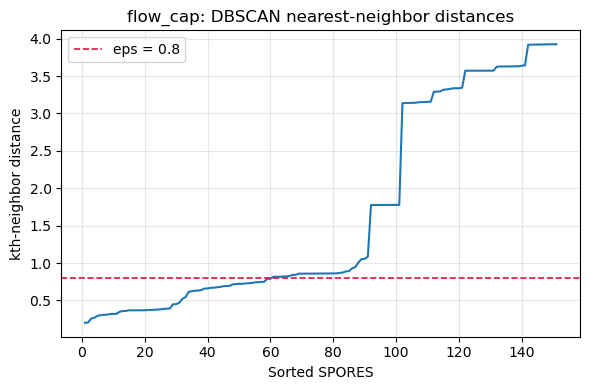

In [12]:
nearest_neighbors = nearest_neighbor_distances(matrix, preset)
plot_nearest_neighbor_curve(
    nearest_neighbors,
    eps=preset.dbscan_eps,
    title=f"{preset.variable}: DBSCAN nearest-neighbor distances",
)

## Fit And Compare Methods

All methods below use the tuning values configured in the selected preset.


In [13]:
labels_by_method = fit_all_methods(matrix, preset)
metrics = validation_metrics(matrix, labels_by_method, pca_components=preset.pca_components).round(3)
params = method_parameter_table(preset).join(metrics[["clusters", "noise_points"]], rsuffix="_output")
params

,pca_components,clusters,epsilon,min_samples,cut_distance,clusters_output,noise_points
method,,,,,,,
K-means,6,4.0,NaN,NaN,NaN,4,0
Hier. (Ward),6,NaN,NaN,NaN,16.0,6,0
Hier. (Complete),6,NaN,NaN,NaN,5.2,6,0
Hier. (Single),6,NaN,NaN,NaN,3.1,5,0
DBSCAN,6,NaN,0.8,12.0,NaN,3,70


In [14]:
metrics

,clusters,noise_points,silhouette,davies_bouldin,calinski_harabasz
method,,,,,
K-means,4,0,0.449,0.846,49.902
Hier. (Ward),6,0,0.570,0.651,90.497
Hier. (Complete),6,0,0.574,0.541,78.566
Hier. (Single),5,0,0.522,0.503,41.440
DBSCAN,3,70,0.638,0.477,177.436


(<Figure size 1400x400 with 3 Axes>,
 array([<Axes: title={'center': 'Silhouette'}>,
        <Axes: title={'center': 'Davies Bouldin'}>,
        <Axes: title={'center': 'Calinski Harabasz'}>], dtype=object))

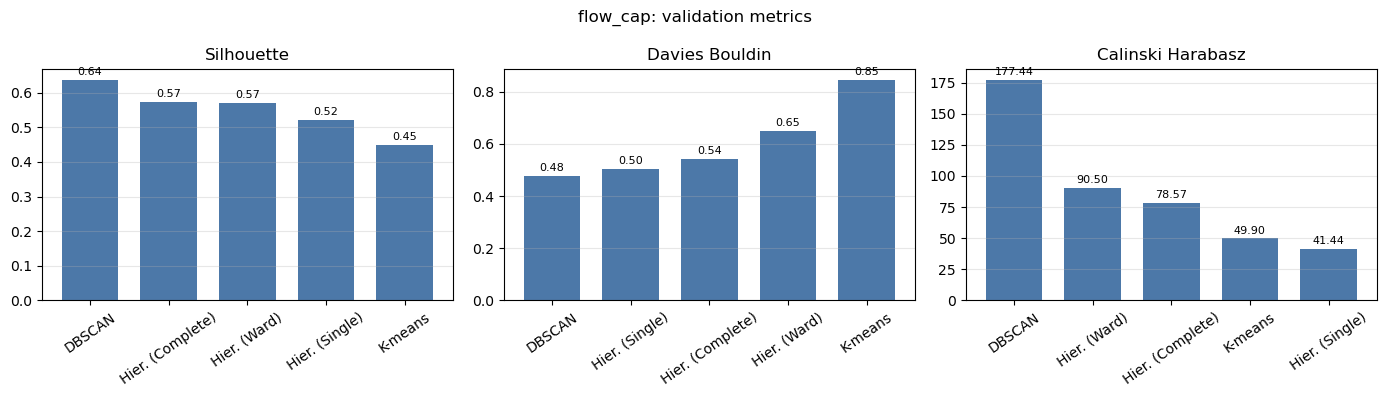

In [15]:
plot_validation_metrics(metrics, title=f"{preset.variable}: validation metrics")

## Inspect Selected Method

Change `SELECTED_METHOD` in the configuration cell to inspect another clustering result without changing the feature matrix or tuning presets.

In [16]:
labels = labels_by_method[SELECTED_METHOD]
result_tables = selected_method_tables(matrix, labels)
label_counts = labels.value_counts().sort_index().rename("solutions")
label_counts

cluster
1     10
2     10
3     10
4     10
5    111
Name: solutions, dtype: int64

(<Figure size 1100x400 with 1 Axes>,
 <Axes: title={'center': 'flow_cap: Hier. (Single) SPORES allocation'}, xlabel='SPORES family', ylabel='Cluster'>)

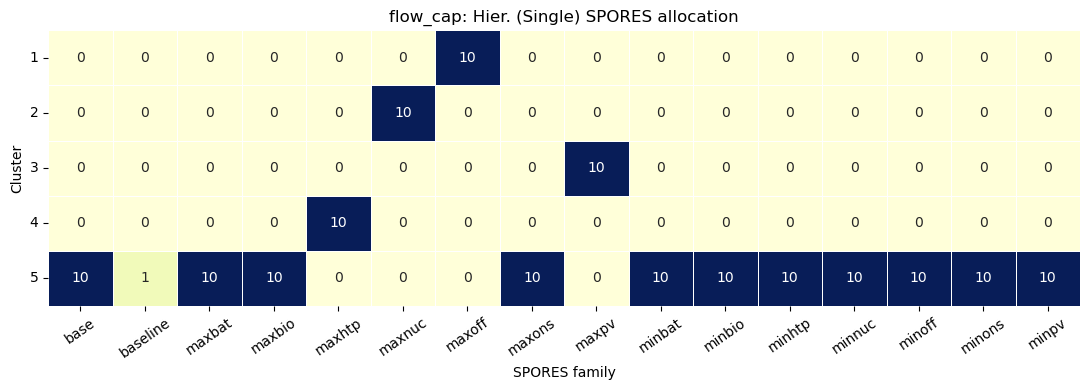

In [17]:
family_counts = result_tables["family_counts"]
plot_family_heatmap(family_counts, title=f"{preset.variable}: {SELECTED_METHOD} SPORES allocation")

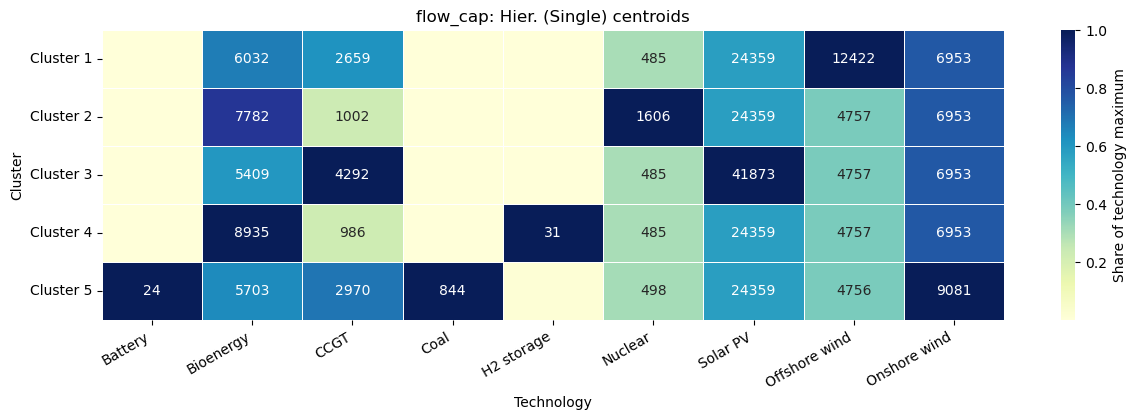

In [18]:
cluster_summary = result_tables["cluster_summary"]
if preset.matrix_kind == "timeseries":
    plot_timeseries_centroids(cluster_summary, title=f"{preset.variable}: {SELECTED_METHOD} centroids")
else:
    plot_capacity_centroids(cluster_summary, title=f"{preset.variable}: {SELECTED_METHOD} centroids")

In [19]:
representatives = result_tables["representatives"]
representatives

1     maxoff_spore_7
2     maxnuc_spore_5
3      maxpv_spore_4
4     maxhtp_spore_6
5    minoff_spore_10
Name: representative_spore, dtype: object

In [20]:
scores_2d, pca_2d, _ = pca_scores(matrix, n_components=2)
pd.Series(
    pca_2d.explained_variance_ratio_,
    index=["PC1", "PC2"],
    name="explained_variance_ratio",
).to_frame()

,explained_variance_ratio
PC1,0.263750
PC2,0.151814


(<Figure size 850x620 with 1 Axes>,
 <Axes: title={'center': 'flow_cap: Hier. (Single) labels in PCA space'}, xlabel='PC1', ylabel='PC2'>)

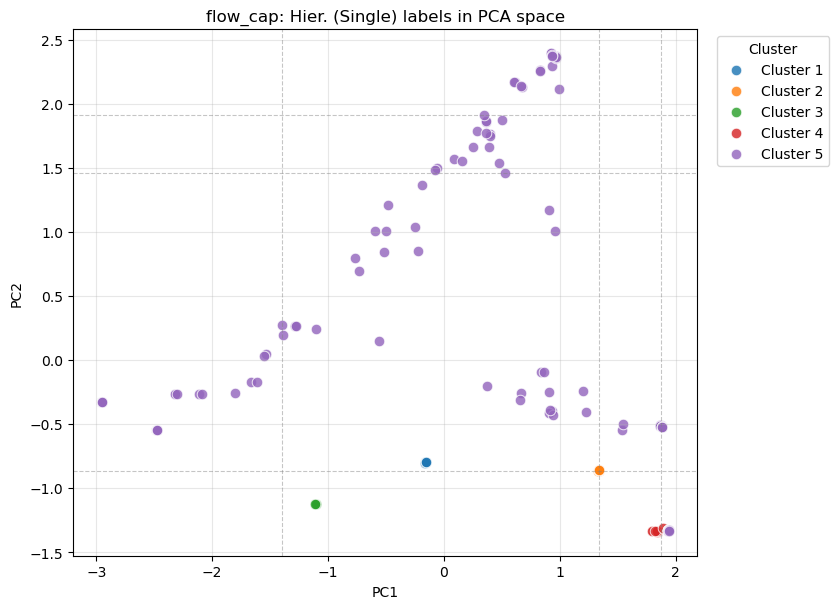

In [21]:
plot_pca_scores(scores_2d, labels, title=f"{preset.variable}: {SELECTED_METHOD} labels in PCA space")

## Export Workbench Tables

Exports small CSV summaries for the currently selected preset and method. The large `.nc` files are never copied.

In [22]:
tables_to_export = {
    "method_parameters": params,
    "validation_metrics": metrics,
    "elbow": elbow,
    "nearest_neighbor_distances": nearest_neighbors,
    "selected_label_counts": label_counts,
    "selected_family_counts": family_counts,
    "selected_cluster_summary": cluster_summary,
    "selected_representatives": representatives,
    "selected_labelled_matrix": result_tables["labelled_matrix"],
}

if EXPORT_RESULTS:
    written = export_workbench_tables(tables_to_export, OUTPUT_DIR / SELECTED_METHOD.replace(" ", "_").replace(".", ""))
else:
    written = []
written

[PosixPath('/Users/lucazerotre/Desktop/TU Delft/Project Work Thesis/new_calliope_review/outputs/clustering_workbench/flow_cap_default/Hier_(Single)/method_parameters.csv'),
 PosixPath('/Users/lucazerotre/Desktop/TU Delft/Project Work Thesis/new_calliope_review/outputs/clustering_workbench/flow_cap_default/Hier_(Single)/validation_metrics.csv'),
 PosixPath('/Users/lucazerotre/Desktop/TU Delft/Project Work Thesis/new_calliope_review/outputs/clustering_workbench/flow_cap_default/Hier_(Single)/elbow.csv'),
 PosixPath('/Users/lucazerotre/Desktop/TU Delft/Project Work Thesis/new_calliope_review/outputs/clustering_workbench/flow_cap_default/Hier_(Single)/nearest_neighbor_distances.csv'),
 PosixPath('/Users/lucazerotre/Desktop/TU Delft/Project Work Thesis/new_calliope_review/outputs/clustering_workbench/flow_cap_default/Hier_(Single)/selected_label_counts.csv'),
 PosixPath('/Users/lucazerotre/Desktop/TU Delft/Project Work Thesis/new_calliope_review/outputs/clustering_workbench/flow_cap_default